# MNIST Flow / Diffusion：可选训练、生成与 ODE 数值分析

实现全部在 `bs6221_flow/*.py`；本 Notebook 只设置参数、调用和展示。

In [1]:
from pathlib import Path
import os, sys, torch
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'bs6221_flow').is_dir())
sys.path.insert(0, str(ROOT))
os.environ.setdefault('MPLCONFIGDIR', str(ROOT / '.cache/matplotlib'))
torch.set_num_threads(4)
from bs6221_flow.sampling import load_flow, generate_images, compare_solvers, solve_ode
from bs6221_flow.training import train_model
from bs6221_flow.presentation import show_training, forward_demo, probability_paths, generation_demo, diffusion_demo, show_saved_numerics
from bs6221_flow.widgets import generation_panel, numerics_panel
from IPython.display import display
DEVICE = os.environ.get('BS6221_DEVICE', 'auto')
FLOW_WEIGHTS = None  # None: frozen 15,000-step EMA; or your training run's best.pt
model = load_flow(FLOW_WEIGHTS, DEVICE)
print('Device:', next(model.parameters()).device, '| weights SHA-256:', model.flow_weight_sha256)

Matplotlib is building the font cache; this may take a moment.


Device: cpu | weights SHA-256: c164a6eca06211d611f9e67149c872d8e20818121351975d84955143457bb559


## 环境与可选训练
先按 README 创建环境。默认直接加载预训练模型，下面不会自动训练。
历史训练曲线来自保存的 checkpoint；Flow 的速度 MSE 与 DDPM 的噪声 MSE 不可直接比较。
历史训练有放回抽样，图中 epoch 是等效遍历次数；新训练按随机打乱后的完整数据遍历。
续训的验证协议与早期不同，分开画线；没有记录的训练损失保持缺失。

,Original training configuration
architecture,conditional_tiny_unet_v1
num_classes,10
channels,24
diffusion_steps,100
batch_size,64
learning_rate,0.001
ema_decay,0.995
seed,42
split_sha256,42af1dd4f83dc1cc662714730942fd0d98070b300aac9b...
completed_steps,15000


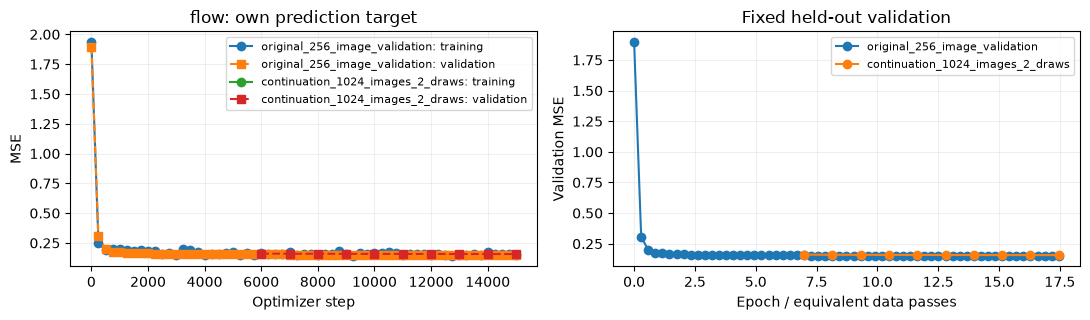

,step,epoch,training_mse,validation_mse,phase,learning_rate
63,8000,9.309091,NaN,0.159111,continuation_1024_images_2_draws,0.000244
64,9000,10.472727,NaN,0.158588,continuation_1024_images_2_draws,0.000207
65,10000,11.636364,NaN,0.158330,continuation_1024_images_2_draws,0.000165
66,11000,12.800000,NaN,0.157899,continuation_1024_images_2_draws,0.000123
67,12000,13.963636,NaN,0.157642,continuation_1024_images_2_draws,0.000086
68,13000,15.127273,NaN,0.157311,continuation_1024_images_2_draws,0.000056
69,14000,16.290909,NaN,0.157167,continuation_1024_images_2_draws,0.000037
70,15000,17.454545,NaN,0.157004,continuation_1024_images_2_draws,0.000030


,Original training configuration
architecture,conditional_tiny_unet_v1
num_classes,10
channels,24
diffusion_steps,100
batch_size,64
learning_rate,0.001
ema_decay,0.995
seed,42
split_sha256,42af1dd4f83dc1cc662714730942fd0d98070b300aac9b...
completed_steps,20000


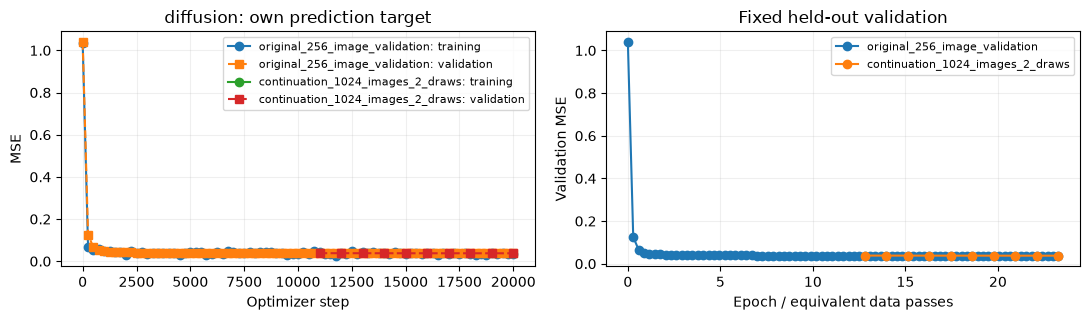

,step,epoch,training_mse,validation_mse,phase,learning_rate
83,13000,15.127273,NaN,0.038002,continuation_1024_images_2_draws,0.000244
84,14000,16.290909,NaN,0.037936,continuation_1024_images_2_draws,0.000207
85,15000,17.454545,NaN,0.037850,continuation_1024_images_2_draws,0.000165
86,16000,18.618182,NaN,0.037806,continuation_1024_images_2_draws,0.000123
87,17000,19.781818,NaN,0.037767,continuation_1024_images_2_draws,0.000086
88,18000,20.945455,NaN,0.037732,continuation_1024_images_2_draws,0.000056
89,19000,22.109091,NaN,0.037715,continuation_1024_images_2_draws,0.000037
90,20000,23.272727,NaN,0.037707,continuation_1024_images_2_draws,0.000030


,step,epoch,training_mse,validation_mse,phase,learning_rate
0,1,0.001164,1.032715,1.039659,original_256_image_validation,NaN
1,250,0.290909,0.066672,0.125662,original_256_image_validation,NaN
2,500,0.581818,0.052784,0.065571,original_256_image_validation,NaN
3,750,0.872727,0.057140,0.051538,original_256_image_validation,NaN
4,1000,1.163636,0.048868,0.047209,original_256_image_validation,NaN
...,...,...,...,...,...,...
86,16000,18.618182,NaN,0.037806,continuation_1024_images_2_draws,0.000123
87,17000,19.781818,NaN,0.037767,continuation_1024_images_2_draws,0.000086
88,18000,20.945455,NaN,0.037732,continuation_1024_images_2_draws,0.000056
89,19000,22.109091,NaN,0.037715,continuation_1024_images_2_draws,0.000037


In [2]:
show_training(kind='flow')
show_training(kind='diffusion')

In [3]:
RUN_TRAINING = os.environ.get('BS6221_RUN_TRAINING', '0') == '1'
TRAIN_CONFIG = dict(kind='flow', steps=1000, batch_size=64, learning_rate=3e-4,
                    ema_decay=.995, seed=42, validation_every=250,
                    validation_samples=256, device_preference=DEVICE)
# To train full epochs: remove steps and add epochs=1. Each epoch covers 55,000 images.
print('Optional training parameters:', TRAIN_CONFIG)
if RUN_TRAINING:
    training_folder, history = train_model(**TRAIN_CONFIG)
    show_training(history=history, kind=TRAIN_CONFIG['kind'])
    if TRAIN_CONFIG['kind'] == 'flow':
        model = load_flow(training_folder / 'best.pt', DEVICE)

Optional training parameters: {'kind': 'flow', 'steps': 1000, 'batch_size': 64, 'learning_rate': 0.0003, 'ema_decay': 0.995, 'seed': 42, 'validation_every': 250, 'validation_samples': 256, 'device_preference': 'cpu'}


## 1. 图片 → 噪声 → 概率路径 → 模型生成
先看真实训练图片逐渐加噪。Flow 插值使用固定噪声；DDPM 链每步引入新噪声。
图片到噪声记 s∈[0,1]；Flow 训练/生成记 t=1−s，噪声 t=0，图片 t=1。

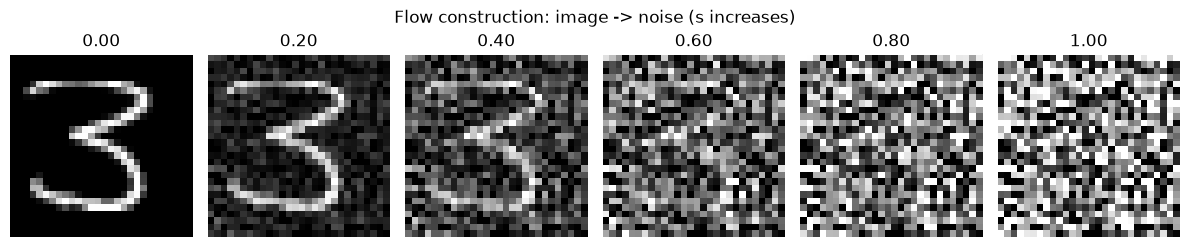

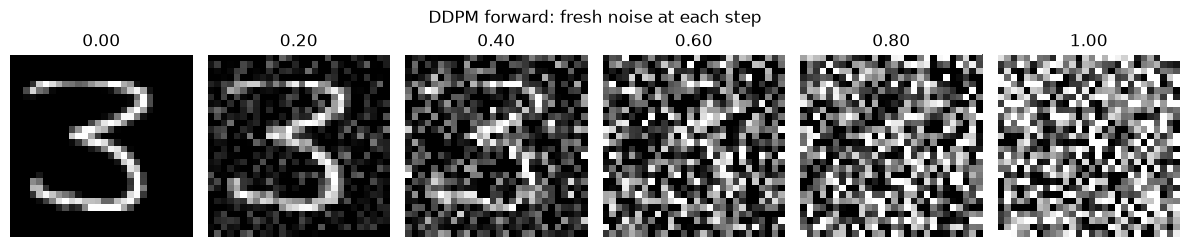

{'flow': [tensor([[[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
             -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
             -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
             -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
            [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
             -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
             -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
             -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
            [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
             -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
             -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
             -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
            [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
 

In [4]:
forward_demo(digit=3, seed=42)

### 样本空间中的构造概率路径
每张图片是 784 维向量。这里只用训练图片拟合固定 PCA 轴，投影噪声到图片的经验样本路径。
颜色表示配对的真实数字类别；这不是网络学到的生成轨迹，也不是 784 维概率密度。

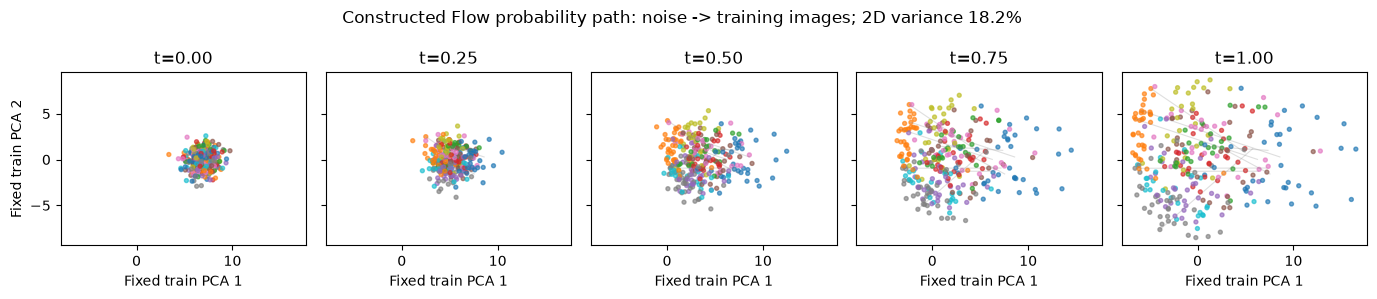

This is an empirical projected path, not learned generation or a 784D density. Time t=1-s of the image-to-noise view.


{'clouds': [tensor([[ 7.1667e+00, -9.2991e-01],
          [ 7.3466e+00,  9.9700e-01],
          [ 6.2537e+00,  1.1035e-02],
          [ 7.5517e+00, -1.5777e+00],
          [ 5.7697e+00,  1.1939e+00],
          [ 6.3436e+00, -1.2783e+00],
          [ 8.5856e+00,  2.7870e-01],
          [ 4.9628e+00,  7.4402e-01],
          [ 8.0780e+00,  9.0573e-01],
          [ 7.0383e+00,  1.3874e-02],
          [ 5.3160e+00, -1.7447e-01],
          [ 6.7366e+00,  1.1726e+00],
          [ 5.8771e+00, -4.9580e-01],
          [ 6.4110e+00,  1.6494e+00],
          [ 7.4749e+00, -1.8048e+00],
          [ 7.0806e+00,  8.4433e-01],
          [ 6.4240e+00, -3.2987e-01],
          [ 6.9913e+00, -1.2148e+00],
          [ 7.8917e+00, -9.1683e-02],
          [ 7.4191e+00,  1.3809e-01],
          [ 7.0681e+00,  1.5298e+00],
          [ 5.7464e+00,  9.5739e-01],
          [ 5.7757e+00,  5.9171e-01],
          [ 5.6653e+00, -1.7216e+00],
          [ 6.2546e+00, -2.4817e-01],
          [ 6.5306e+00, -4.7824e-01],
  

In [5]:
probability_paths(seed=42, samples=300)

### 模型实际怎样生成图片
Flow 每一步用网络预测速度，再由求解器更新状态。DDPM 预测噪声并执行反向随机采样。
下面使用新噪声，不使用前面真实图片的终点。DDPM 的“采样进度”不是 Flow 的时间参数。

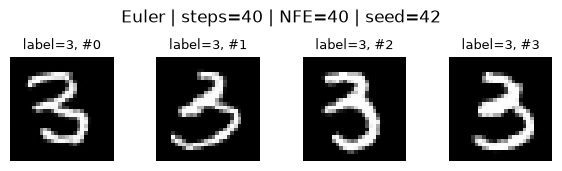

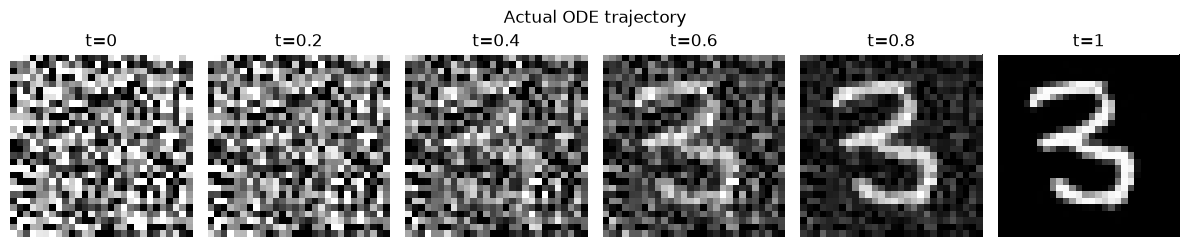

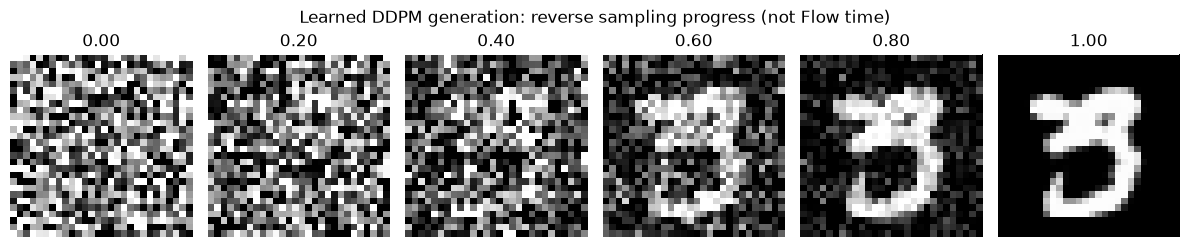

{'states': [tensor([[[[ 1.9269e+00,  1.4873e+00,  9.0072e-01, -2.1055e+00,  6.7842e-01,
             -1.2345e+00, -4.3067e-02, -1.6047e+00, -7.5214e-01,  1.6487e+00,
             -3.9248e-01, -1.4036e+00, -7.2788e-01, -5.5943e-01, -7.6884e-01,
              7.6245e-01,  1.6423e+00, -1.5960e-01, -4.9740e-01,  4.3959e-01,
             -7.5813e-01,  1.0783e+00,  8.0080e-01,  1.6806e+00,  1.2791e+00,
              1.2964e+00,  6.1047e-01,  1.3347e+00],
            [-2.3162e-01,  4.1759e-02, -2.5158e-01,  8.5986e-01, -1.3847e+00,
             -8.7124e-01, -2.2337e-01,  1.7174e+00,  3.1888e-01, -4.2452e-01,
              3.0572e-01, -7.7459e-01, -1.5576e+00,  9.9564e-01, -8.7979e-01,
             -6.0114e-01, -1.2742e+00,  2.1228e+00, -1.2347e+00, -4.8791e-01,
             -9.1382e-01, -6.5814e-01,  7.8024e-02,  5.2581e-01, -4.8799e-01,
              1.1914e+00, -8.1401e-01, -7.3599e-01],
            [-1.4032e+00,  3.6004e-02, -6.3477e-02,  6.7561e-01, -9.7807e-02,
              1.8446e+00, 

In [6]:
generation_demo(net=model, digit=3, seed=42, steps=40)
diffusion_demo(digit=3, seed=42, step_seed=43, device_preference=DEVICE)

## 2. 选择数字和噪声，再看生成过程
选择数字、噪声种子、求解器和步数。先预览噪声，再生成图片；相同模型、标签和初始噪声可重复。
相同 NFE 比较会使用同一噪声；改变噪声尺度属于扰动实验，默认标准高斯尺度为 1。
实际路径来自积分过程，不是图片插值。可调用 generate_images(..., noise=你的张量, net=model)。

In [7]:
playground = generation_panel(model)
display(playground)

## 3. ODE 数值分析：参数、成本和收敛性
NFE = 步数 × 每步网络调用数：Euler 1、Heun 2、RK4 4。相同步数与相同 NFE 是不同预算。
下面先展示原冻结模型的实验记录；它们不是这次重新计算的结果，也不对应自训练模型。
理论阶需要正则性和渐近步长条件。RMSE 相对于近似参考解，不是真实图片误差。
稳定性测试中的线性刚性不证明这个神经网络 ODE 刚性。

,Original experiment provenance
source,Original 2026-10-02 experiment; exported 2026-...
configuration,configuration.json
reference_audit,reference_check.json
summary,run_summary.json
caveats,"Reference refinement is diagnostic, not exact ..."


,method,raw_local_defect_slope,normalized_defect_slope,global_error_slope
0,Euler,1.982153,0.982153,1.023405
1,Heun,2.986601,1.986601,2.041248
2,RK4,4.991049,3.991049,4.045151


,method,theoretical_order,fit_steps,observed_slope,r_squared
0,Euler,1,"160,320,640",1.018709,0.999011
1,Heun,2,"160,320,640",1.773375,0.999934
2,RK4,4,"160,320,640",2.793103,0.990895


,method,steps,h,nfe,median_rmse,mean_rmse,q25,q75,worst_rmse,label_agreement,median_seconds,min_seconds,max_seconds
0,Euler,20,0.050000,20,0.034384,0.047982,0.022944,0.051743,0.391613,0.97,0.166976,0.166810,0.167393
1,Euler,40,0.025000,40,0.018007,0.027493,0.012851,0.026501,0.288433,0.97,0.332565,0.332184,0.334270
2,Euler,80,0.012500,80,0.008766,0.013778,0.006646,0.013202,0.168156,0.97,0.667080,0.667062,0.667892
3,Euler,160,0.006250,160,0.004667,0.005783,0.003430,0.006738,0.029256,0.97,1.329399,1.328900,1.329774
4,Euler,320,0.003125,320,0.002216,0.002858,0.001535,0.003216,0.012819,0.97,2.660871,2.659352,2.664803
5,Heun,10,0.100000,20,0.072245,0.076620,0.062160,0.083867,0.279319,0.97,0.167280,0.166774,0.167693
6,Heun,20,0.050000,40,0.031826,0.031880,0.024348,0.036712,0.107547,0.97,0.334485,0.334431,0.334506
7,Heun,40,0.025000,80,0.013849,0.013615,0.010736,0.016345,0.021824,0.97,0.666010,0.665584,0.669933
8,Heun,80,0.012500,160,0.005858,0.006112,0.004752,0.007142,0.013470,0.97,1.331570,1.330336,1.335027
9,Heun,160,0.006250,320,0.002909,0.003189,0.002464,0.003397,0.008490,0.97,2.663066,2.662007,2.665335


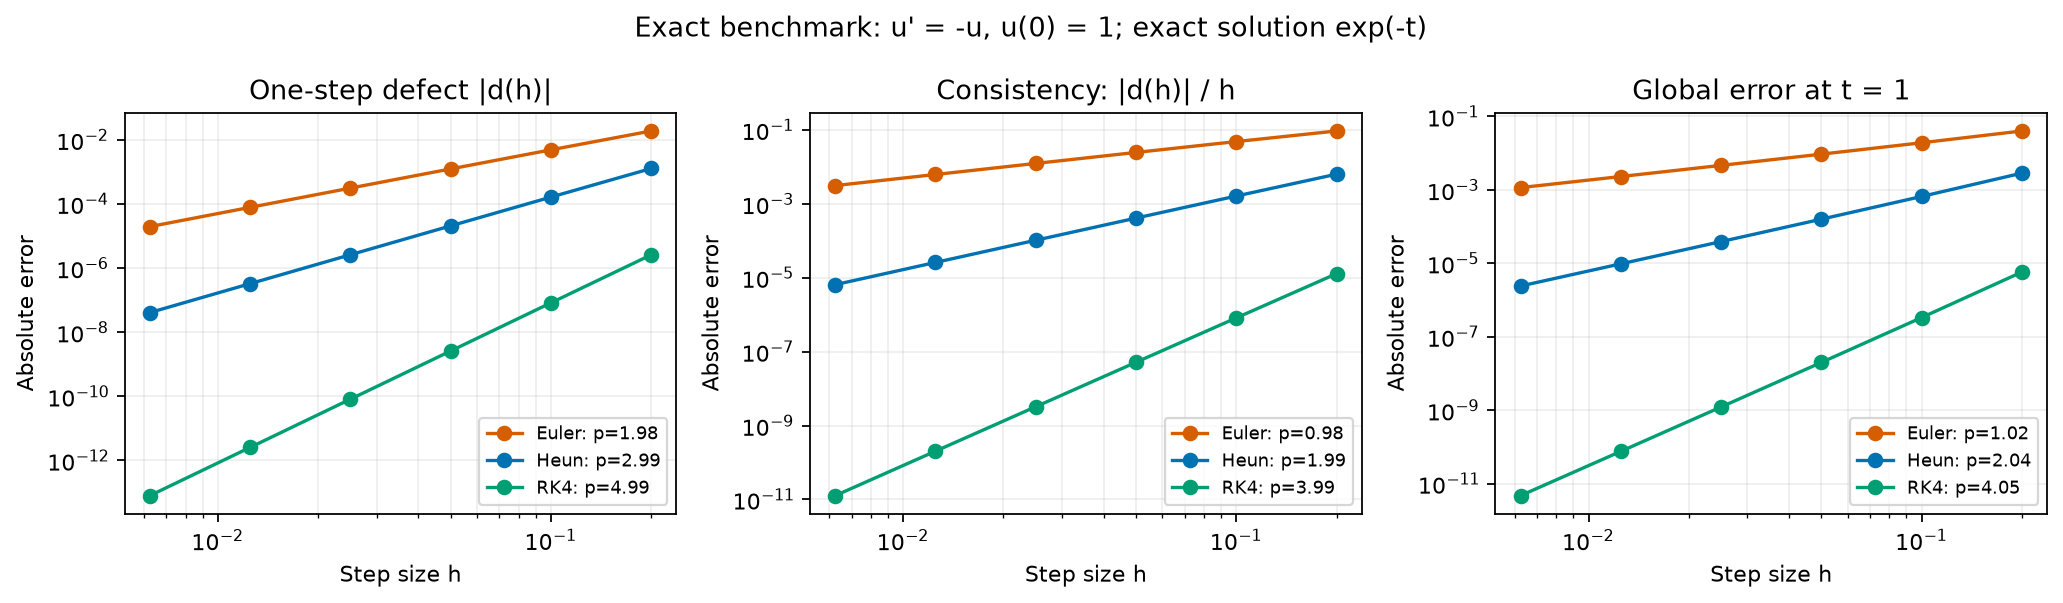

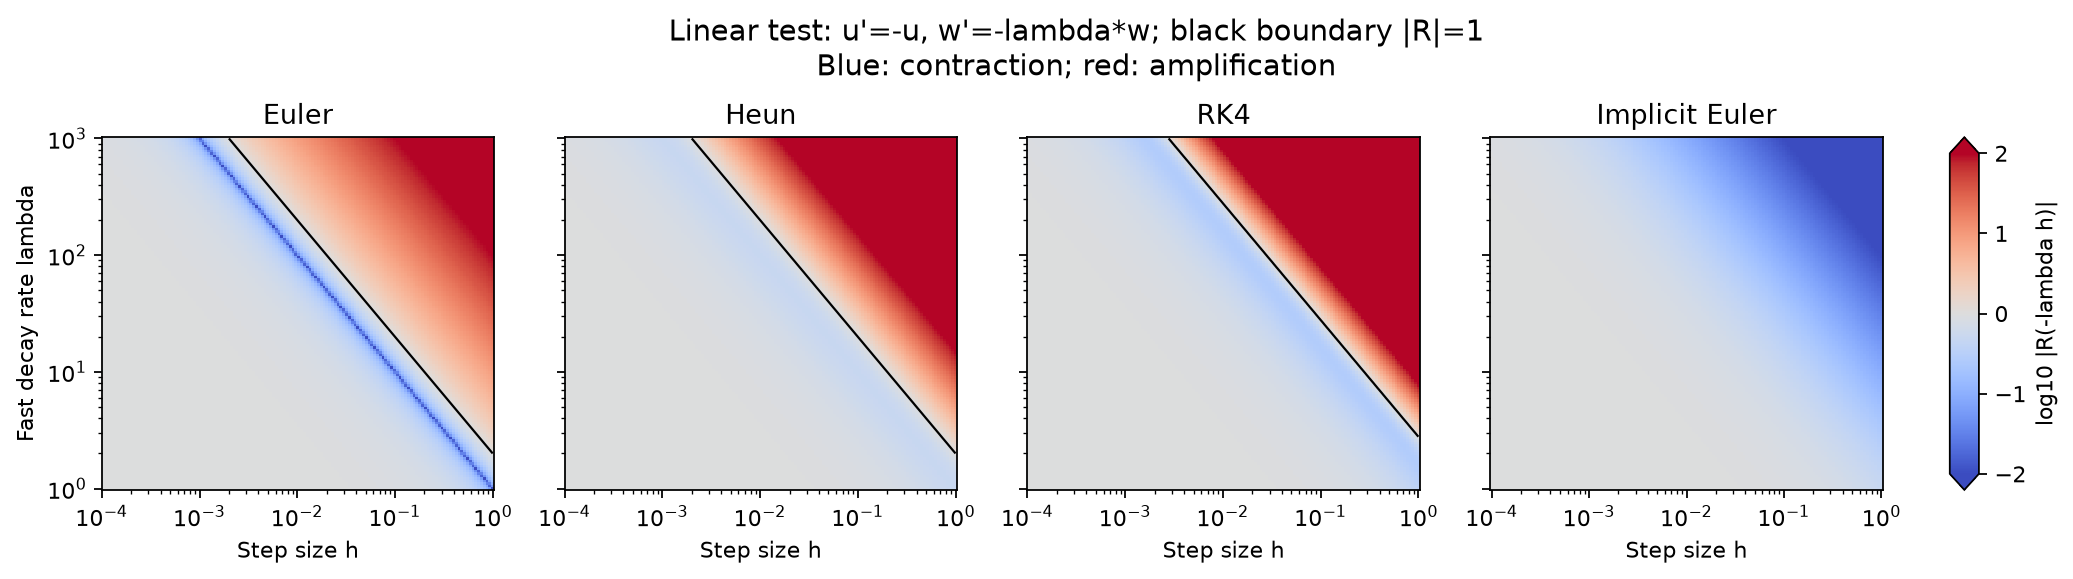

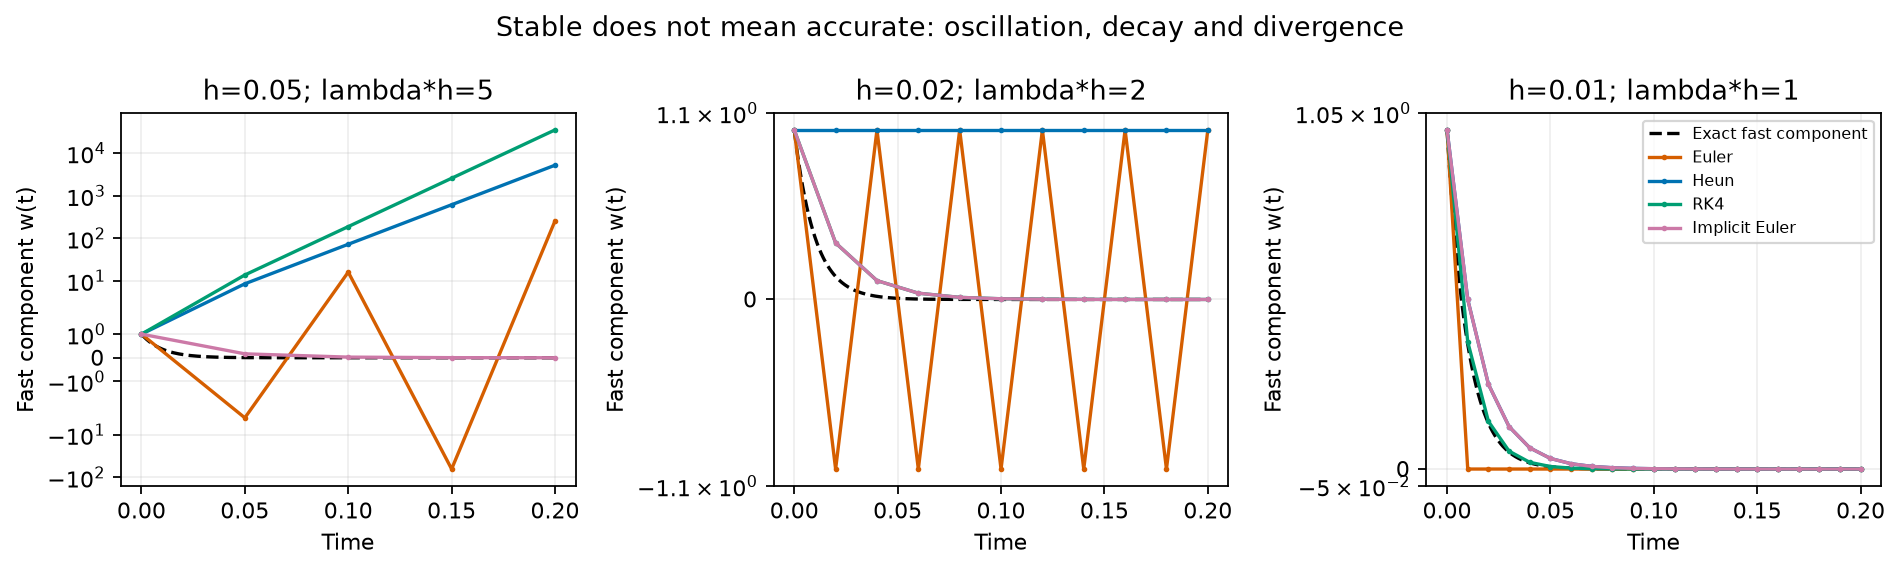

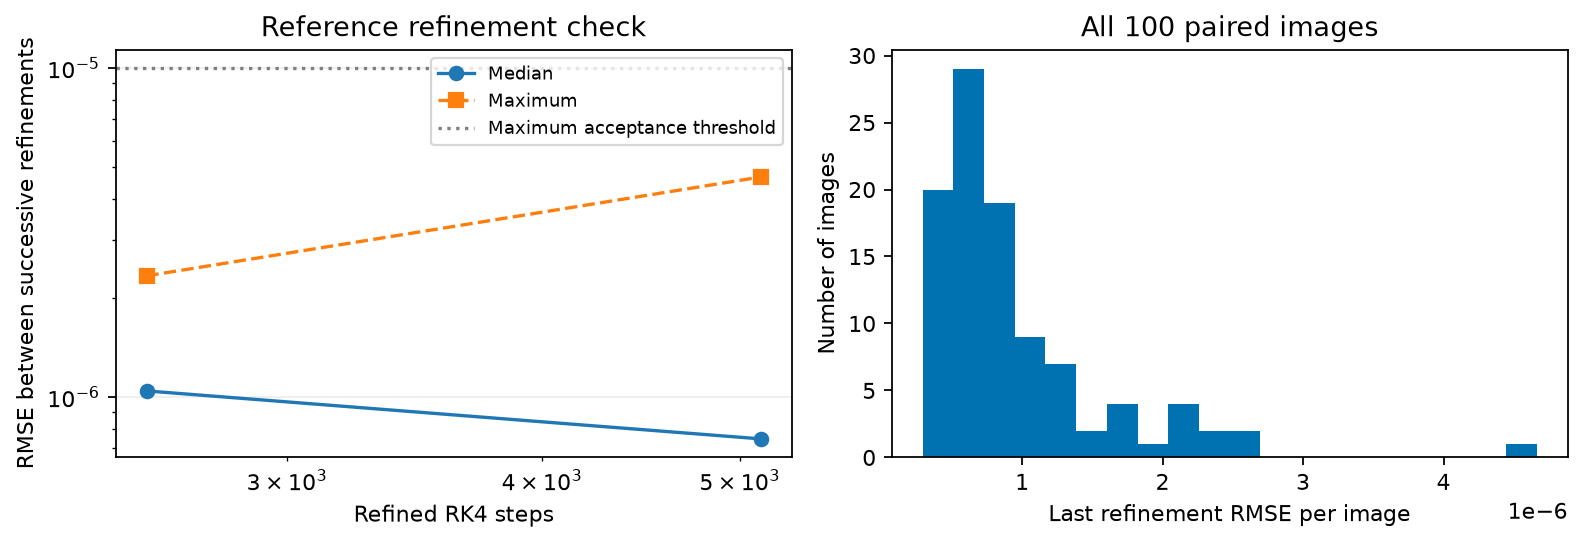

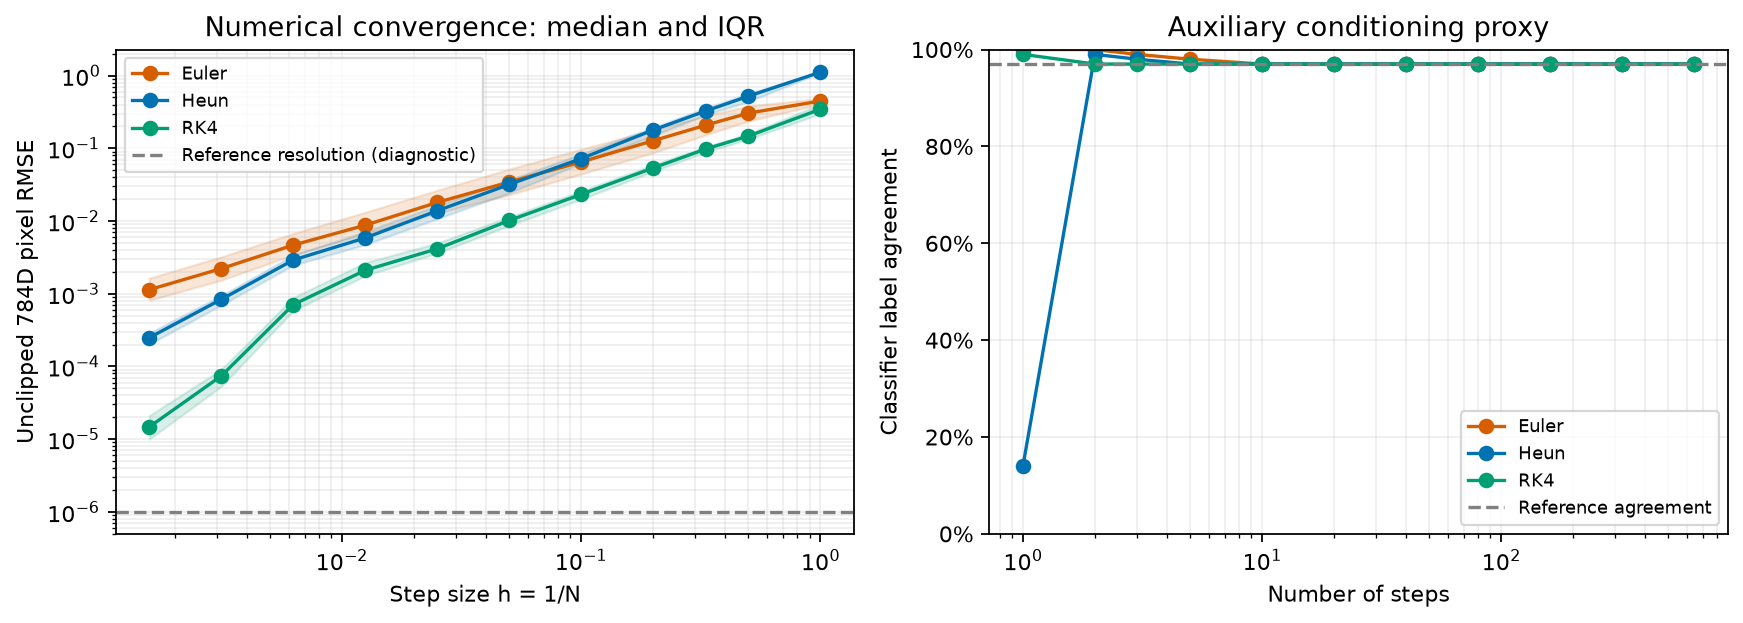

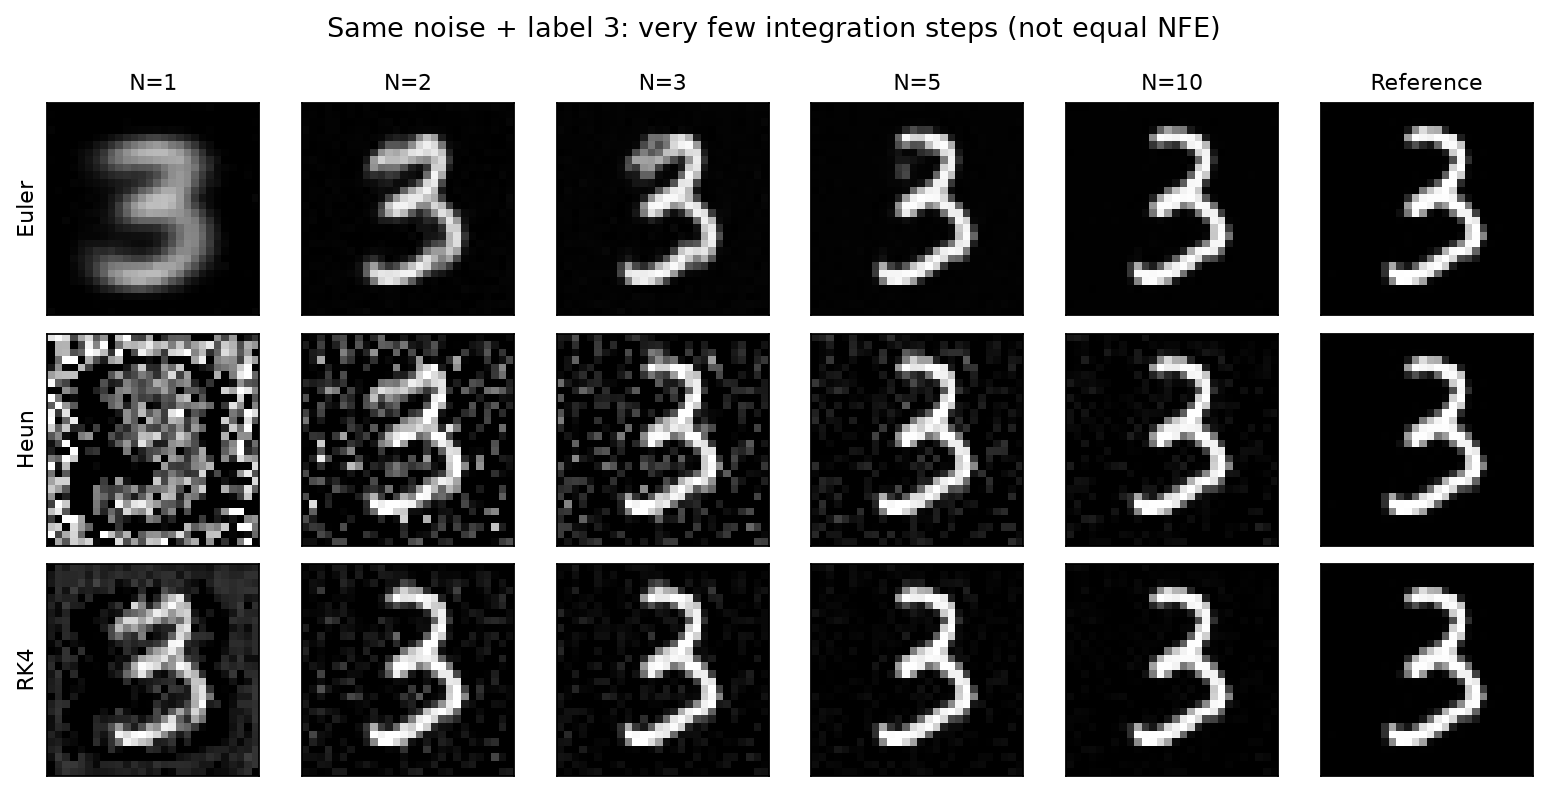

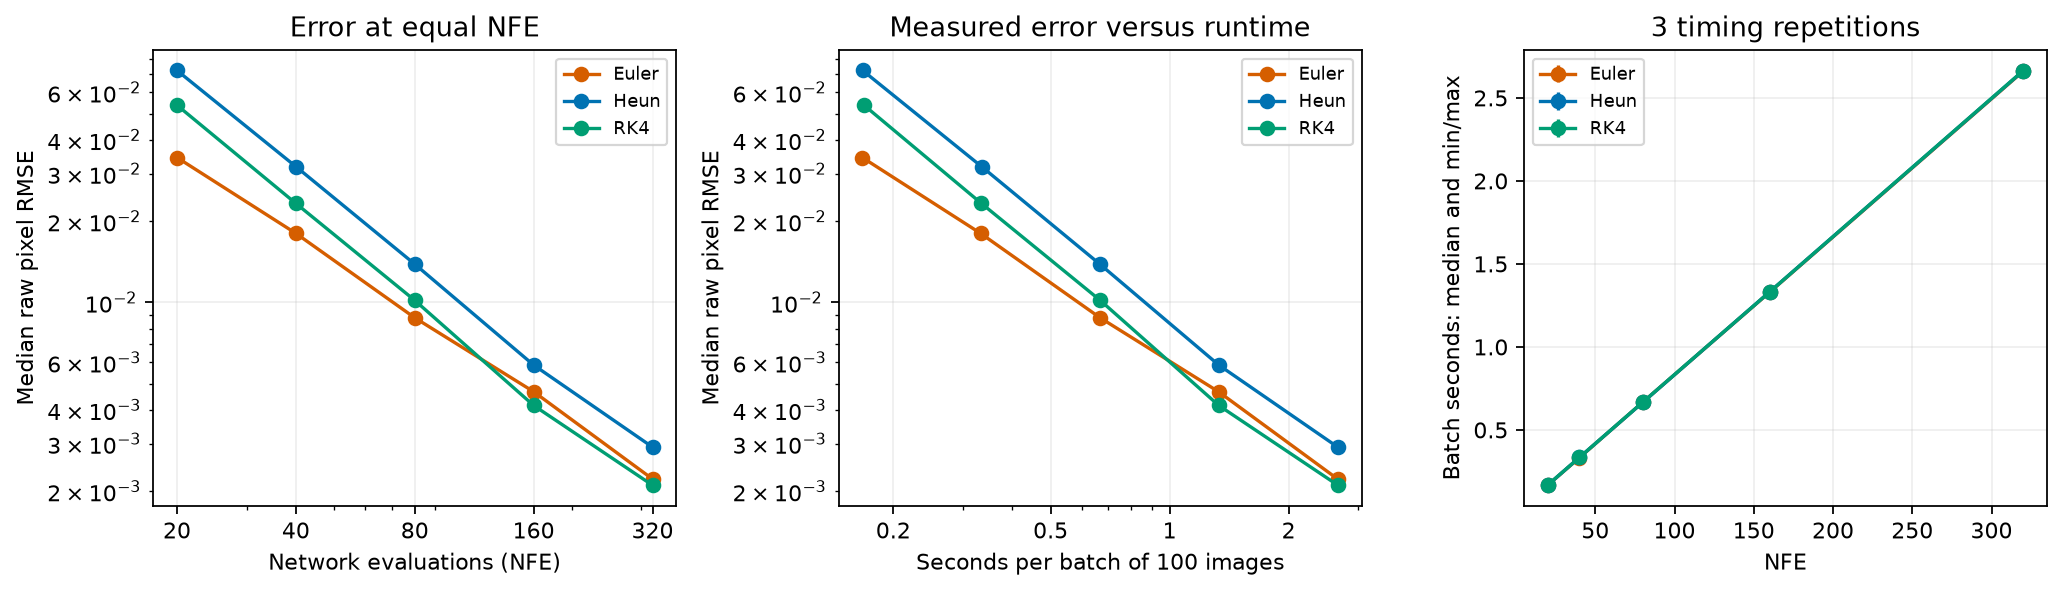

In [8]:
show_saved_numerics()

### 自定义小规模数值实验（点击才计算）
改变样本数、步数列表、NFE、参考分辨率与计时重复。各方法使用同一个当前模型、标签和噪声。
CPU float64 RK4 两级加密检验参考分辨率；未通过时不要报告可信收敛阶。
小样本适合探索，正式结论应使用完整独立样本与更精细参考。

In [9]:
ode_panel = numerics_panel(model)
display(ode_panel)